In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(f"Folder: {dirname}")
    print(f"Number of files: {len(filenames)}")

    # First 5 files
    for file in filenames[:5]:
        print(file)

    print("-" * 50)

Folder: /kaggle/input
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset/all_data
Number of files: 0
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset/all_data/validation
Number of files: 1
radiologyvaldata.csv
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset/all_data/validation/radiology
Number of files: 7
captions.txt
cuis.txt
keywords.txt
licences.txt
valdata.csv
--------------------------------------------------
Folder: /kaggle/input/datasets/virajbagal/roco-dataset/

In [ ]:
import pandas as pd

train_csv = "/kaggle/input/datasets/virajbagal/roco-dataset/all_data/train/radiologytraindata.csv"

df = pd.read_csv(train_csv)

print(df.head())
print("\nColumns:")
print(df.columns)
print("\nShape:")
print(df.shape)

           id                                    name  \
0  ROCO_00002          PMC4083729_AMHSR-4-14-g002.jpg   
1  ROCO_00003       PMC2837471_IJD2009-150251.001.jpg   
2  ROCO_00004  PMC2505281_11999_2007_30_Fig6_HTML.jpg   
3  ROCO_00005       PMC3745845_IJD2013-683423.005.jpg   
4  ROCO_00007   PMC4917066_amjcaserep-17-301-g001.jpg   

                                             caption  
0   Computed tomography scan in axial view showin...  
1   Bacterial contamination occurred after comple...  
2   The patient had residual paralysis of the han...  
3    Panoramic radiograph after immediate loading.\n  
4   Plain abdomen x-ray: Multiple air levels at t...  

Columns:
Index(['id', 'name', 'caption'], dtype='object')

Shape:
(65450, 3)


In [ ]:
# ==========================
# IMPORT LIBRARIES
# ==========================

import os
import re
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

print("PyTorch Version:", torch.__version__)
print("TorchVision Version:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

PyTorch Version: 2.10.0+cu128
TorchVision Version: 0.25.0+cu128
Device: cuda


In [ ]:
# ==========================================
# LOAD DATASET
# ==========================================

BASE_PATH = "/kaggle/input/datasets/virajbagal/roco-dataset/all_data"

TRAIN_CSV = f"{BASE_PATH}/train/radiologytraindata.csv"
VAL_CSV   = f"{BASE_PATH}/validation/radiologyvaldata.csv"
TEST_CSV  = f"{BASE_PATH}/test/radiologytestdata.csv"

TRAIN_IMG_DIR = f"{BASE_PATH}/train/radiology/images"
VAL_IMG_DIR   = f"{BASE_PATH}/validation/radiology/images"
TEST_IMG_DIR  = f"{BASE_PATH}/test/radiology/images"

# ==========================================
# READ CSV FILES
# ==========================================

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train Shape :", train_df.shape)
print("Val Shape   :", val_df.shape)
print("Test Shape  :", test_df.shape)

print("\nColumns:")
print(train_df.columns)

# ==========================================
# CREATE IMAGE PATHS
# ==========================================

train_df["image_path"] = train_df["name"].apply(
    lambda x: os.path.join(TRAIN_IMG_DIR, x)
)

val_df["image_path"] = val_df["name"].apply(
    lambda x: os.path.join(VAL_IMG_DIR, x)
)

test_df["image_path"] = test_df["name"].apply(
    lambda x: os.path.join(TEST_IMG_DIR, x)
)

print("\nSample Image Path:")
print(train_df["image_path"].iloc[0])

print("\nSample Caption:")
print(train_df["caption"].iloc[0][:200])

Train Shape : (65450, 3)
Val Shape   : (8180, 3)
Test Shape  : (8179, 3)

Columns:
Index(['id', 'name', 'caption'], dtype='object')

Sample Image Path:
/kaggle/input/datasets/virajbagal/roco-dataset/all_data/train/radiology/images/PMC4083729_AMHSR-4-14-g002.jpg

Sample Caption:
 Computed tomography scan in axial view showing obliteration of the left maxillary sinus



In [ ]:
# ==========================================
# DATASET INTEGRITY CHECK
# ==========================================

def check_images(df):

    missing = 0

    for path in df["image_path"]:
        if not os.path.exists(path):
            missing += 1

    return missing

train_missing = check_images(train_df)
val_missing = check_images(val_df)
test_missing = check_images(test_df)

print("="*50)
print("TRAIN Missing Images :", train_missing)
print("VALIDATION Missing Images :", val_missing)
print("TEST Missing Images :", test_missing)
print("="*50)

total_images = len(train_df) + len(val_df) + len(test_df)

print("\nTotal Samples:", total_images)

TRAIN Missing Images : 30
VALIDATION Missing Images : 5
TEST Missing Images : 3

Total Samples: 81809


In [ ]:
# ==========================================
# REMOVE MISSING IMAGE RECORDS
# ==========================================

train_df = train_df[
    train_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)

val_df = val_df[
    val_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)

test_df = test_df[
    test_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)

print("Train Shape :", train_df.shape)
print("Val Shape   :", val_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (65420, 4)
Val Shape   : (8175, 4)
Test Shape  : (8176, 4)


Train: 65420
Validation: 8175
Test: 8176


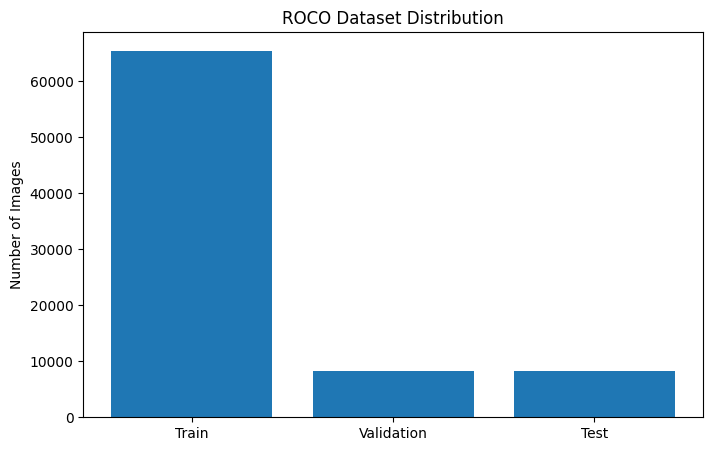

In [ ]:
# ==========================================
# DATASET DISTRIBUTION
# ==========================================

train_count = len(train_df)
val_count = len(val_df)
test_count = len(test_df)

print("Train:", train_count)
print("Validation:", val_count)
print("Test:", test_count)

plt.figure(figsize=(8,5))

plt.bar(
    ["Train","Validation","Test"],
    [train_count,val_count,test_count]
)

plt.title("ROCO Dataset Distribution")
plt.ylabel("Number of Images")

plt.show()

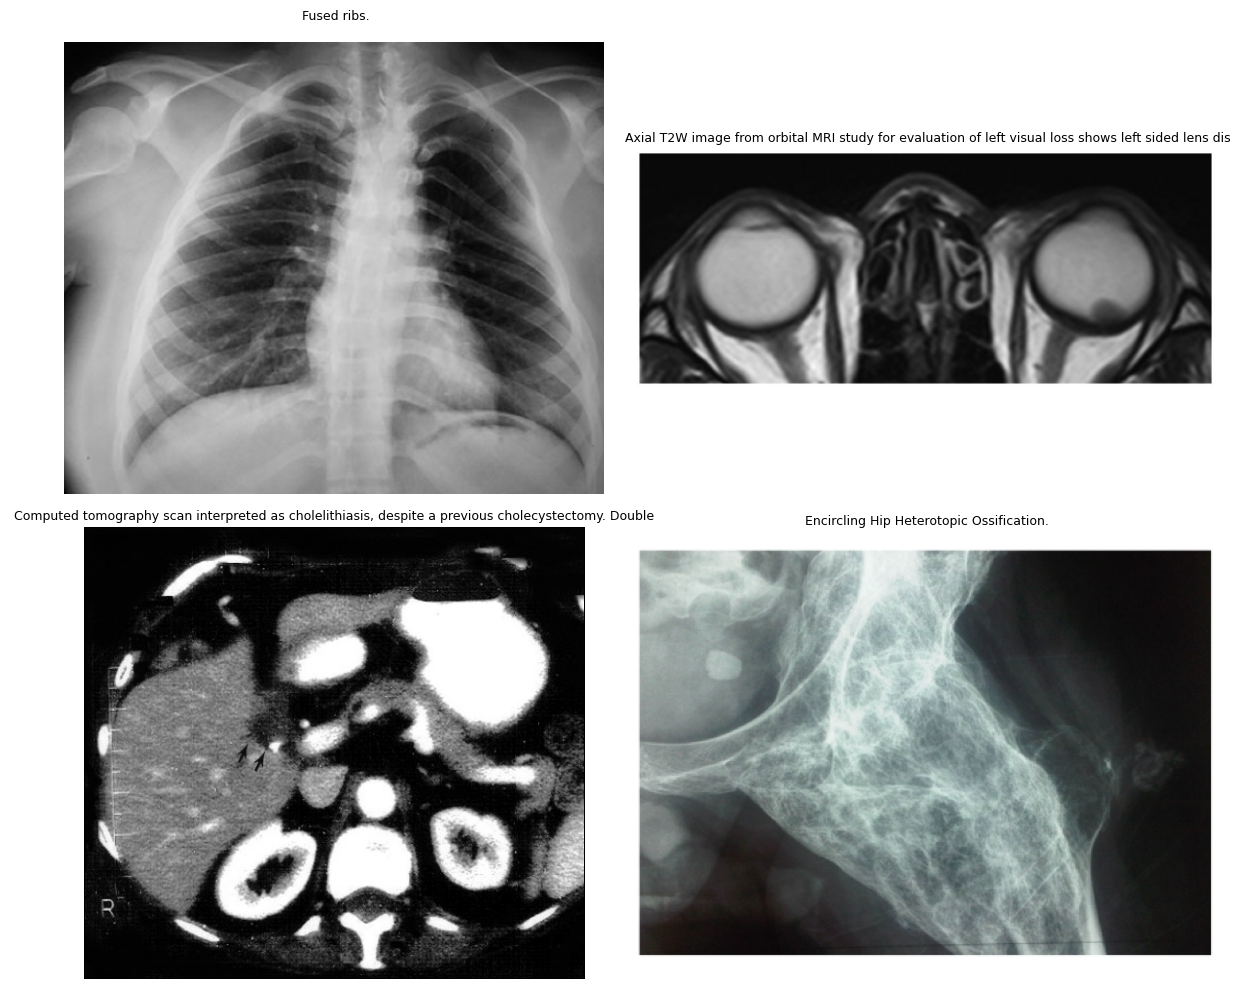

In [ ]:
# ==========================================
# RANDOM IMAGE VISUALIZATION
# ==========================================

sample_df = train_df.sample(4, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for i, (_, row) in enumerate(sample_df.iterrows()):

    img = Image.open(row["image_path"]).convert("RGB")

    axes[i].imshow(img)
    axes[i].set_title(
        row["caption"][:100],
        fontsize=9
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

Average Width : 600.83
Average Height: 558.5


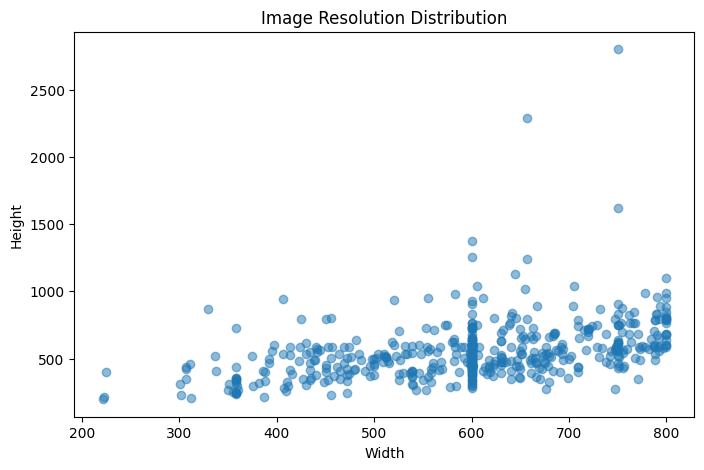

In [ ]:
# ==========================================
# IMAGE RESOLUTION ANALYSIS
# ==========================================

sample_images = train_df.sample(500, random_state=42)

widths = []
heights = []

for path in sample_images["image_path"]:

    img = Image.open(path)

    widths.append(img.size[0])
    heights.append(img.size[1])

print("Average Width :", np.mean(widths))
print("Average Height:", np.mean(heights))

plt.figure(figsize=(8,5))

plt.scatter(widths, heights, alpha=0.5)

plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

count    65420.000000
mean        20.216600
std         16.022262
min          0.000000
25%         10.000000
50%         16.000000
75%         25.000000
max        410.000000
Name: caption_length, dtype: float64


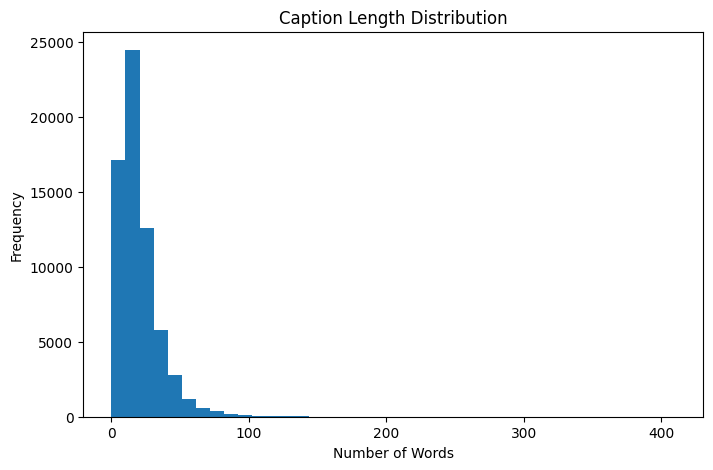

In [ ]:
# ==========================================
# CAPTION LENGTH ANALYSIS
# ==========================================

train_df["caption_length"] = train_df["caption"].apply(
    lambda x: len(str(x).split())
)

print(train_df["caption_length"].describe())

plt.figure(figsize=(8,5))

plt.hist(
    train_df["caption_length"],
    bins=40
)

plt.title("Caption Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# ==========================================
# REMOVE EMPTY CAPTIONS
# ==========================================

train_df["caption"] = train_df["caption"].fillna("").astype(str)
val_df["caption"] = val_df["caption"].fillna("").astype(str)
test_df["caption"] = test_df["caption"].fillna("").astype(str)

train_df = train_df[
    train_df["caption"].str.strip() != ""
].reset_index(drop=True)

val_df = val_df[
    val_df["caption"].str.strip() != ""
].reset_index(drop=True)

test_df = test_df[
    test_df["caption"].str.strip() != ""
].reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 65419
Validation: 8175
Test: 8176


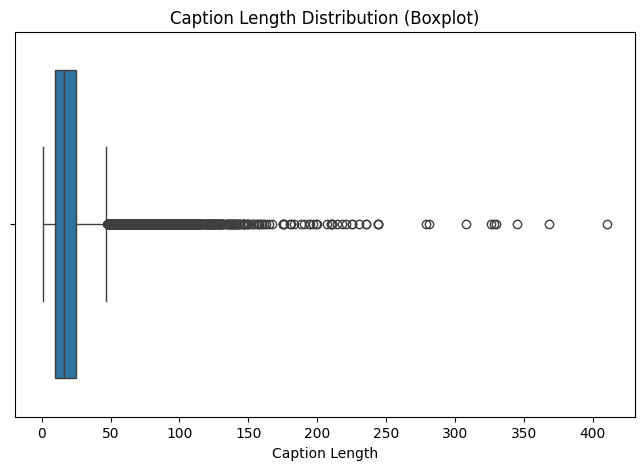

In [ ]:
# ==========================================
# CAPTION LENGTH BOXPLOT
# ==========================================

train_df["caption_length"] = train_df["caption"].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(8,5))

sns.boxplot(
    x=train_df["caption_length"]
)

plt.title("Caption Length Distribution (Boxplot)")
plt.xlabel("Caption Length")

plt.show()

In [ ]:
# ==========================================
# VOCABULARY ANALYSIS
# ==========================================

all_words = []

for caption in train_df["caption"]:

    words = str(caption).lower().split()

    all_words.extend(words)

word_counts = Counter(all_words)

print("Total Words:", len(all_words))
print("Unique Vocabulary:", len(word_counts))

Total Words: 1322570
Unique Vocabulary: 66517


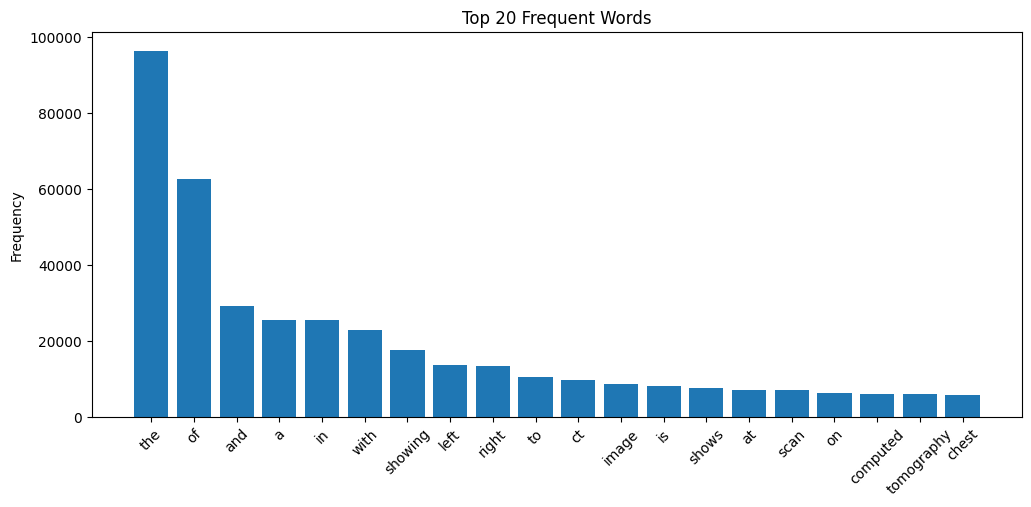

In [ ]:
# ==========================================
# TOP 20 WORDS
# ==========================================

top_words = word_counts.most_common(20)

words = [x[0] for x in top_words]
freqs = [x[1] for x in top_words]

plt.figure(figsize=(12,5))

plt.bar(words, freqs)

plt.xticks(rotation=45)

plt.title("Top 20 Frequent Words")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# ==========================================
# CLEAN MEDICAL CAPTIONS
# ==========================================

def clean_caption(text):

    text = str(text).lower()

    # remove line breaks
    text = text.replace("\n", " ")

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    # keep letters + numbers
    text = re.sub(r"[^a-z0-9\s]", "", text)

    return text.strip()


train_df["clean_caption"] = train_df["caption"].apply(clean_caption)
val_df["clean_caption"] = val_df["caption"].apply(clean_caption)
test_df["clean_caption"] = test_df["caption"].apply(clean_caption)

print(train_df[["caption","clean_caption"]].head())

                                             caption  \
0   Computed tomography scan in axial view showin...   
1   Bacterial contamination occurred after comple...   
2   The patient had residual paralysis of the han...   
3    Panoramic radiograph after immediate loading.\n   
4   Plain abdomen x-ray: Multiple air levels at t...   

                                       clean_caption  
0  computed tomography scan in axial view showing...  
1  bacterial contamination occurred after complet...  
2  the patient had residual paralysis of the hand...  
3       panoramic radiograph after immediate loading  
4  plain abdomen xray multiple air levels at the ...  


In [ ]:
# ==========================================
# VOCABULARY AFTER CLEANING
# ==========================================

all_words_clean = []

for caption in train_df["clean_caption"]:

    all_words_clean.extend(caption.split())

clean_vocab = Counter(all_words_clean)

print("Total Clean Words :", len(all_words_clean))
print("Unique Clean Vocabulary :", len(clean_vocab))

Total Clean Words : 1316476
Unique Clean Vocabulary : 40948


Rare Words Removed : 30524
Words Retained : 10424


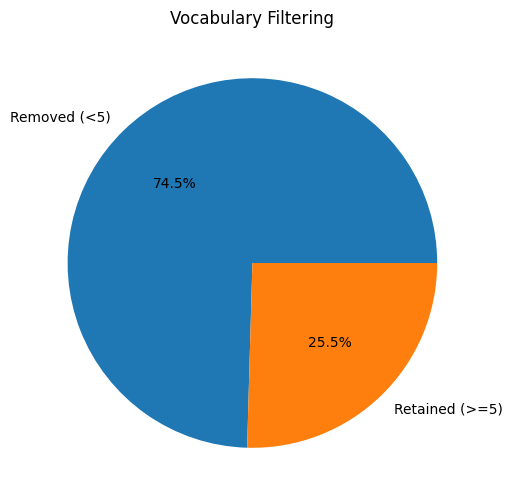

In [ ]:
# ==========================================
# RARE WORD ANALYSIS
# ==========================================

rare_words = []
frequent_words = []

for word, count in clean_vocab.items():

    if count < 5:
        rare_words.append(word)
    else:
        frequent_words.append(word)

print("Rare Words Removed :", len(rare_words))
print("Words Retained :", len(frequent_words))

plt.figure(figsize=(6,6))

plt.pie(
    [len(rare_words), len(frequent_words)],
    labels=["Removed (<5)", "Retained (>=5)"],
    autopct="%1.1f%%"
)

plt.title("Vocabulary Filtering")

plt.show()

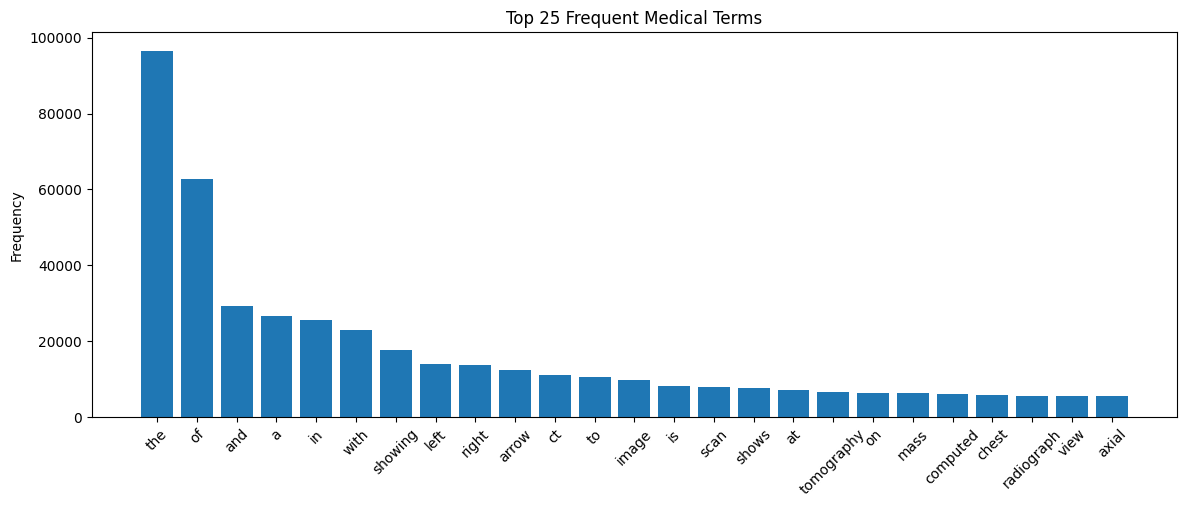

In [ ]:
# ==========================================
# TOP WORDS AFTER CLEANING
# ==========================================

top_words = clean_vocab.most_common(25)

words = [x[0] for x in top_words]
freqs = [x[1] for x in top_words]

plt.figure(figsize=(14,5))

plt.bar(words, freqs)

plt.xticks(rotation=45)

plt.title("Top 25 Frequent Medical Terms")

plt.ylabel("Frequency")

plt.show()

count    65419.000000
mean        20.123756
std         15.917603
min          1.000000
25%         10.000000
50%         16.000000
75%         25.000000
max        410.000000
Name: clean_length, dtype: float64


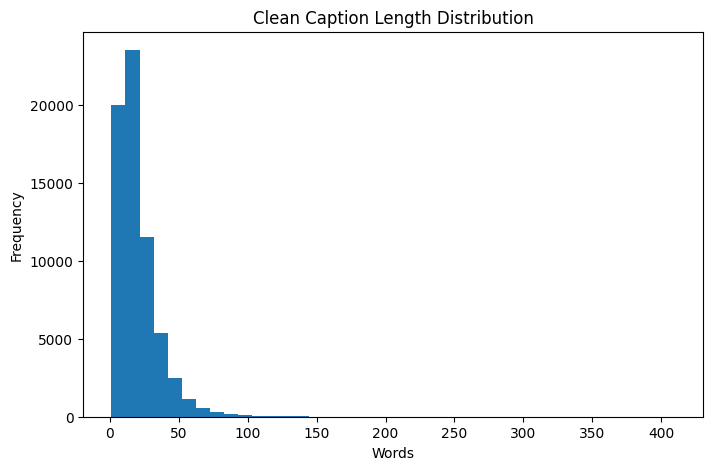

In [ ]:
# ==========================================
# CLEAN CAPTION LENGTH
# ==========================================

train_df["clean_length"] = train_df["clean_caption"].apply(
    lambda x: len(x.split())
)

print(train_df["clean_length"].describe())

plt.figure(figsize=(8,5))

plt.hist(
    train_df["clean_length"],
    bins=40
)

plt.title("Clean Caption Length Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

In [ ]:
# ==========================================
# RESNET50 IMAGE TRANSFORM
# ==========================================

IMG_SIZE = 224

transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform Ready")

Transform Ready


In [ ]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla P100-PCIE-16GB


In [ ]:
!nvidia-smi

Thu Jun 25 09:57:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             26W /  250W |       3MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ==========================================
# LOAD PRETRAINED RESNET50
# ==========================================

weights = ResNet50_Weights.DEFAULT

resnet = resnet50(weights=weights)

resnet = nn.Sequential(
    *list(resnet.children())[:-1]
)

resnet.eval()

print("ResNet50 Loaded Successfully")

ResNet50 Loaded Successfully


In [ ]:
# ==========================================
# SINGLE IMAGE FEATURE EXTRACTION
# ==========================================

def extract_feature(image_path):

    image = Image.open(image_path).convert("RGB")

    image = transform(image)

    image = image.unsqueeze(0)

    with torch.no_grad():

        feature = resnet(image)

    feature = feature.squeeze()

    return feature.numpy()


sample_image = train_df["image_path"].iloc[0]

feature = extract_feature(sample_image)

print("Feature Shape:", feature.shape)

Feature Shape: (2048,)


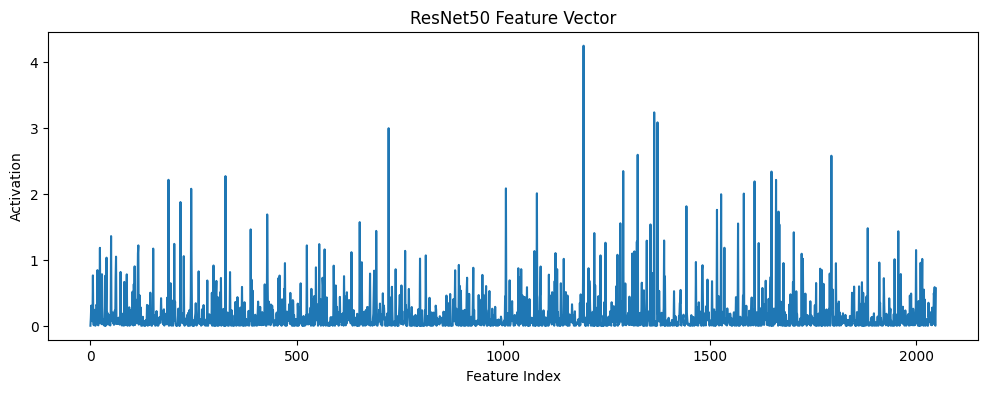

In [ ]:
# ==========================================
# FEATURE VECTOR VISUALIZATION
# ==========================================

plt.figure(figsize=(12,4))

plt.plot(feature)

plt.title("ResNet50 Feature Vector")
plt.xlabel("Feature Index")
plt.ylabel("Activation")

plt.show()

In [ ]:
# ==========================================
# EXTRACT FEATURES FROM 500 IMAGES
# ==========================================

sample_df = train_df.sample(
    500,
    random_state=42
).reset_index(drop=True)

features = []

start_time = time.time()

for idx, row in sample_df.iterrows():

    feat = extract_feature(row["image_path"])

    features.append(feat)

    if (idx+1) % 100 == 0:
        print(f"{idx+1} images processed")

end_time = time.time()

features = np.array(features)

print("\nFeature Matrix Shape:", features.shape)

print(
    "\nProcessing Time:",
    round(end_time-start_time,2),
    "seconds"
)

100 images processed
200 images processed
300 images processed
400 images processed
500 images processed

Feature Matrix Shape: (500, 2048)

Processing Time: 46.69 seconds


Reduced Shape: (500, 2)


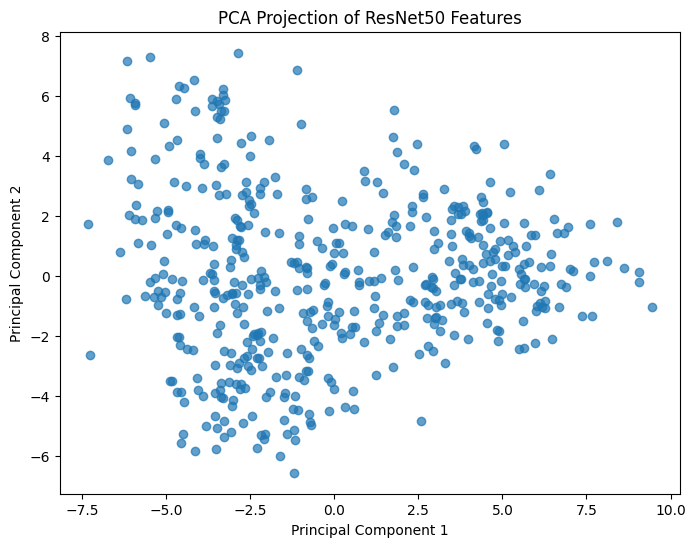

In [ ]:
# ==========================================
# PCA VISUALIZATION
# ==========================================

pca = PCA(n_components=2)

reduced_features = pca.fit_transform(features)

print("Reduced Shape:", reduced_features.shape)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced_features[:,0],
    reduced_features[:,1],
    alpha=0.7
)

plt.title("PCA Projection of ResNet50 Features")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

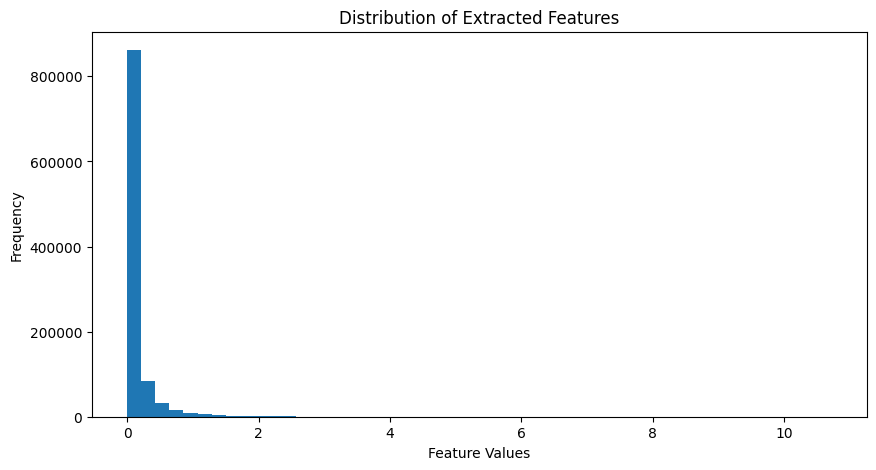

In [ ]:
# ==========================================
# FEATURE DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(
    features.flatten(),
    bins=50
)

plt.title("Distribution of Extracted Features")

plt.xlabel("Feature Values")
plt.ylabel("Frequency")

plt.show()

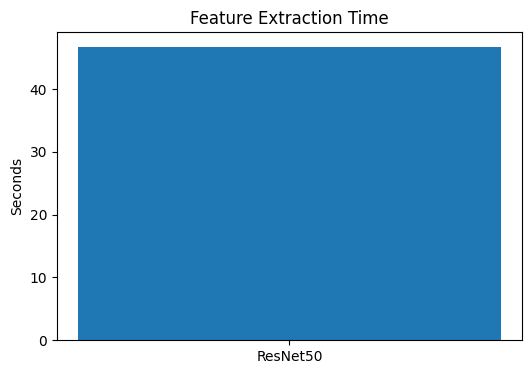

Average Time Per Image: 0.09337999999999999 seconds


In [ ]:
# ==========================================
# PROCESSING TIME GRAPH
# ==========================================

processing_time = round(
    end_time-start_time,
    2
)

plt.figure(figsize=(6,4))

plt.bar(
    ["ResNet50"],
    [processing_time]
)

plt.ylabel("Seconds")

plt.title("Feature Extraction Time")

plt.show()

print(
    "Average Time Per Image:",
    processing_time/500,
    "seconds"
)

Memory Usage (%) : 7.0
Available Memory (GB): 29.16


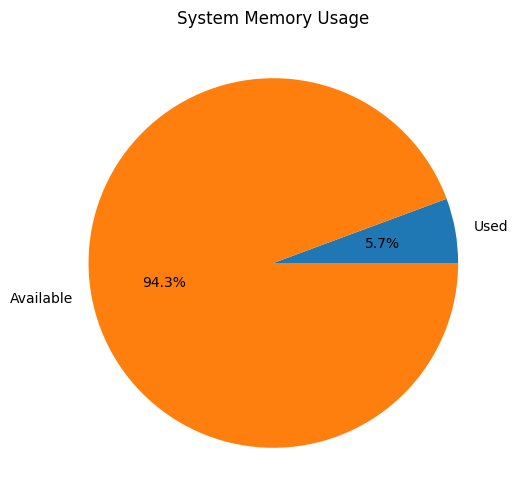

In [ ]:
# ==========================================
# MEMORY ANALYSIS
# ==========================================

import psutil

memory = psutil.virtual_memory()

print("Memory Usage (%) :", memory.percent)

print("Available Memory (GB):",
      round(memory.available/1024**3,2))

plt.figure(figsize=(6,6))

plt.pie(
    [memory.used, memory.available],
    labels=["Used","Available"],
    autopct="%1.1f%%"
)

plt.title("System Memory Usage")

plt.show()

In [ ]:
# ==========================================
# VOCABULARY FILTERING
# ==========================================

min_word_freq = 5

vocab_words = [
    word
    for word, count in clean_vocab.items()
    if count >= min_word_freq
]

print("Original Vocabulary :", len(clean_vocab))
print("Filtered Vocabulary :", len(vocab_words))

Original Vocabulary : 40948
Filtered Vocabulary : 10424


**Create Vocabulary Dictionary**

In [ ]:
# ==========================================
# BUILD VOCABULARY
# ==========================================

special_tokens = [
    "<PAD>",
    "<START>",
    "<END>",
    "<UNK>"
]

vocab = special_tokens + sorted(vocab_words)

word2idx = {
    word: idx
    for idx, word in enumerate(vocab)
}

idx2word = {
    idx: word
    for word, idx in word2idx.items()
}

VOCAB_SIZE = len(vocab)

print("Vocabulary Size:", VOCAB_SIZE)

print("\nSample Tokens:")

for i in range(10):
    print(i, "->", idx2word[i])

Vocabulary Size: 10428

Sample Tokens:
0 -> <PAD>
1 -> <START>
2 -> <END>
3 -> <UNK>
4 -> 0
5 -> 001
6 -> 005
7 -> 01
8 -> 010
9 -> 02


In [ ]:
# ==========================================
# WORD TO TOKEN ENCODING VISUALIZATION
# ==========================================

sample_caption = train_df["clean_caption"].iloc[0]

print("Original Caption:\n")
print(sample_caption)

print("\nWord Encoding:\n")

for word in sample_caption.split():

    print(
        f"{word} ---> {word2idx.get(word)}"
    )

Original Caption:

computed tomography scan in axial view showing obliteration of the left maxillary sinus

Word Encoding:

computed ---> 2105
tomography ---> 9610
scan ---> 8373
in ---> 4720
axial ---> 1126
view ---> 10175
showing ---> 8623
obliteration ---> 6490
of ---> 6560
the ---> 9462
left ---> 5384
maxillary ---> 5788
sinus ---> 8681


In [ ]:
# ==========================================
# ENCODE CAPTIONS
# ==========================================

def encode_caption(caption):

    words = caption.split()

    encoded = [word2idx["<START>"]]

    for word in words:

        encoded.append(
            word2idx.get(
                word,
                word2idx["<UNK>"]
            )
        )

    encoded.append(word2idx["<END>"])

    return encoded


sample_caption = train_df[
    "clean_caption"
].iloc[0]

encoded_caption = encode_caption(
    sample_caption
)

print("Original Caption:")
print(sample_caption)

print("\nEncoded:")
print(encoded_caption[:30])

print("\nLength:", len(encoded_caption))

Original Caption:
computed tomography scan in axial view showing obliteration of the left maxillary sinus

Encoded:
[1, 2105, 9610, 8373, 4720, 1126, 10175, 8623, 6490, 6560, 9462, 5384, 5788, 8681, 2]

Length: 15


In [ ]:
# ==========================================
# COMPLETE ENCODING PIPELINE
# ==========================================

print("Original Caption:\n")
print(sample_caption)

print("\nWords:\n")
print(sample_caption.split())

print("\nEncoded Tokens:\n")
print(encoded_caption)

Original Caption:

computed tomography scan in axial view showing obliteration of the left maxillary sinus

Words:

['computed', 'tomography', 'scan', 'in', 'axial', 'view', 'showing', 'obliteration', 'of', 'the', 'left', 'maxillary', 'sinus']

Encoded Tokens:

[1, 2105, 9610, 8373, 4720, 1126, 10175, 8623, 6490, 6560, 9462, 5384, 5788, 8681, 2]


In [ ]:
# ==========================================
# MAX CAPTION LENGTH
# ==========================================

all_lengths = train_df[
    "clean_caption"
].apply(
    lambda x: len(
        encode_caption(x)
    )
)

MAX_LEN = int(
    np.percentile(
        all_lengths,
        95
    )
)

print("Maximum Length:", MAX_LEN)

print("\nStatistics:")
print(all_lengths.describe())

Maximum Length: 50

Statistics:
count    65419.000000
mean        22.123756
std         15.917603
min          3.000000
25%         12.000000
50%         18.000000
75%         27.000000
max        412.000000
Name: clean_caption, dtype: float64


In [ ]:
# ==========================================
# PAD ENCODED CAPTIONS
# ==========================================

PAD_IDX = word2idx["<PAD>"]

def pad_caption(encoded_caption):

    if len(encoded_caption) < MAX_LEN:

        encoded_caption += [PAD_IDX] * (
            MAX_LEN - len(encoded_caption)
        )

    else:

        encoded_caption = encoded_caption[:MAX_LEN]

    return encoded_caption


sample_padded = pad_caption(
    encoded_caption
)

print("Original Length:", len(encoded_caption))
print("Padded Length:", len(sample_padded))

print(sample_padded[:20])

Original Length: 50
Padded Length: 50
[1, 2105, 9610, 8373, 4720, 1126, 10175, 8623, 6490, 6560, 9462, 5384, 5788, 8681, 2, 0, 0, 0, 0, 0]


In [ ]:
# ==========================================
# PADDING VISUALIZATION
# ==========================================

print("Before Padding:")
print(encoded_caption)

print("\nLength:", len(encoded_caption))

print("\nAfter Padding:")
print(sample_padded)

print("\nLength:", len(sample_padded))

Before Padding:
[1, 2105, 9610, 8373, 4720, 1126, 10175, 8623, 6490, 6560, 9462, 5384, 5788, 8681, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Length: 50

After Padding:
[1, 2105, 9610, 8373, 4720, 1126, 10175, 8623, 6490, 6560, 9462, 5384, 5788, 8681, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Length: 50


In [ ]:
# ==========================================
# DEVELOPMENT SUBSET
# ==========================================

train_subset = train_df.sample(
    5000,
    random_state=42
).reset_index(drop=True)

val_subset = val_df.sample(
    1000,
    random_state=42
).reset_index(drop=True)

print(train_subset.shape)
print(val_subset.shape)

(5000, 7)
(1000, 5)


In [ ]:
# ==========================================
# CUSTOM DATASET
# ==========================================

class ROCODataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        image = transform(image)

        caption = encode_caption(
            row["clean_caption"]
        )

        caption = pad_caption(caption)

        caption = torch.tensor(
            caption,
            dtype=torch.long
        )

        return image, caption

In [ ]:
# ==========================================
# DATASET TEST
# ==========================================

train_dataset = ROCODataset(
    train_subset
)

image, caption = train_dataset[0]

print("Image Shape :", image.shape)
print("Caption Shape :", caption.shape)

print("\nCaption Tokens:")
print(caption[:20])

Image Shape : torch.Size([3, 224, 224])
Caption Shape : torch.Size([50])

Caption Tokens:
tensor([   1, 3938, 8199,    2,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])


In [ ]:
# ==========================================
# DATALOADER
# ==========================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

images, captions = next(
    iter(train_loader)
)

print("Images Batch:", images.shape)
print("Captions Batch:", captions.shape)

Images Batch: torch.Size([32, 3, 224, 224])
Captions Batch: torch.Size([32, 50])


**Encoder (ResNet50)**

In [ ]:
# ==========================================
# RESNET50 ENCODER
# ==========================================

class EncoderCNN(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = resnet50(
            weights=ResNet50_Weights.DEFAULT
        )

        modules = list(backbone.children())[:-1]

        self.backbone = nn.Sequential(*modules)

        for param in self.backbone.parameters():
            param.requires_grad = False

    def forward(self, images):

        features = self.backbone(images)

        features = features.squeeze(-1)
        features = features.squeeze(-1)

        return features

Decoder (LSTM)

In [ ]:
# ==========================================
# LSTM DECODER
# ==========================================

class DecoderLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_size=256,
        hidden_size=512,
        num_layers=1
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_size
        )

        self.feature_projection = nn.Linear(
            2048,
            embed_size
        )

        self.lstm = nn.LSTM(
            embed_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            vocab_size
        )

    def forward(
        self,
        features,
        captions
    ):

        embeddings = self.embedding(
            captions[:, :-1]
        )

        image_embed = self.feature_projection(
            features
        )

        image_embed = image_embed.unsqueeze(1)

        embeddings = torch.cat(
            [image_embed, embeddings],
            dim=1
        )

        outputs, _ = self.lstm(
            embeddings
        )

        outputs = self.fc(outputs)

        return outputs

**Full Captioning Model**

In [ ]:
# ==========================================
# IMAGE CAPTIONING MODEL
# ==========================================

class ImageCaptionModel(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.encoder = EncoderCNN()

        self.decoder = DecoderLSTM(
            vocab_size=vocab_size
        )

    def forward(
        self,
        images,
        captions
    ):

        features = self.encoder(
            images
        )

        outputs = self.decoder(
            features,
            captions
        )

        return outputs

In [ ]:
# ==========================================
# CREATE MODEL
# ==========================================

model = ImageCaptionModel(
    vocab_size=VOCAB_SIZE
)

device = torch.device("cpu")

model = ImageCaptionModel(
    vocab_size=VOCAB_SIZE
)

model = model.to(device)

print(device)

cpu


In [ ]:
# ==========================================
# NLP EMBEDDING VISUALIZATION
# ==========================================

sample_tokens = torch.tensor(
    encoded_caption[:10]
)

embedded = model.decoder.embedding(
    sample_tokens
)

print("Token Shape:")
print(sample_tokens.shape)

print("\nEmbedding Shape:")
print(embedded.shape)

print("\nExample Token:")
print(sample_tokens[0])

print("\nCorresponding Embedding Vector:")
print(embedded[0][:10])

Token Shape:
torch.Size([10])

Embedding Shape:
torch.Size([10, 256])

Example Token:
tensor(1)

Corresponding Embedding Vector:
tensor([ 0.0497, -0.3491, -0.8276,  0.6107, -0.5661,  0.5035, -2.4780, -0.8166,
        -0.7141, -0.9638], grad_fn=<SliceBackward0>)


In [ ]:
images, captions = next(
    iter(train_loader)
)

images = images.to(device)
captions = captions.to(device)

with torch.no_grad():

    outputs = model(
        images,
        captions
    )

print(outputs.shape)

torch.Size([32, 50, 10428])


In [ ]:
# ==========================================
# LOSS FUNCTION
# ==========================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)

print("Loss Function Ready")

Loss Function Ready


In [ ]:
# ==========================================
# OPTIMIZER
# ==========================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer Ready")

Optimizer Ready


In [ ]:
# ==========================================
# VALIDATION DATASET
# ==========================================

val_dataset = ROCODataset(
    val_subset
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Validation Loader Ready")

Validation Loader Ready


In [ ]:
# ==========================================
# SINGLE TRAINING STEP TEST
# ==========================================

model.train()

images, captions = next(
    iter(train_loader)
)

images = images.to(device)
captions = captions.to(device)

optimizer.zero_grad()

outputs = model(
    images,
    captions
)

outputs = outputs.reshape(
    -1,
    VOCAB_SIZE
)

targets = captions.reshape(-1)

loss = criterion(
    outputs,
    targets
)

loss.backward()

optimizer.step()

print("Loss:", loss.item())

Loss: 9.253515243530273


In [ ]:
# ==========================================
# SMALL TRAINING SUBSET
# ==========================================

small_train = train_df.sample(
    1000,
    random_state=42
).reset_index(drop=True)

small_val = val_df.sample(
    200,
    random_state=42
).reset_index(drop=True)

print("Train:", len(small_train))
print("Val:", len(small_val))

Train: 1000
Val: 200


In [ ]:
# ==========================================
# SMALL DATA LOADERS
# ==========================================

train_dataset = ROCODataset(
    small_train
)

val_dataset = ROCODataset(
    small_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Loaders Ready")

Loaders Ready


In [ ]:
# ==========================================
# VALIDATION FUNCTION
# ==========================================

def evaluate_model(model, loader):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for images, captions in loader:

            images = images.to(device)
            captions = captions.to(device)

            outputs = model(
                images,
                captions
            )

            outputs = outputs.reshape(
                -1,
                VOCAB_SIZE
            )

            targets = captions.reshape(-1)

            loss = criterion(
                outputs,
                targets
            )

            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
device

device(type='cpu')

In [ ]:
# ==========================================
# TRAINING WITH ALL METRICS
# ==========================================

import time
import numpy as np
import pandas as pd

history = []

EPOCHS = 10

for epoch in range(EPOCHS):

    start_time = time.time()

    # --------------------
    # TRAINING
    # --------------------
    model.train()

    train_loss = 0

    train_correct = 0
    train_total = 0

    for images, captions in train_loader:

        images = images.to(device)
        captions = captions.to(device)

        optimizer.zero_grad()

        outputs = model(images, captions)

        outputs = outputs.reshape(
            -1,
            VOCAB_SIZE
        )

        targets = captions.reshape(-1)

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        mask = targets != 0

        train_correct += (
            ((predictions == targets) & mask)
            .sum()
            .item()
        )

        train_total += (
            mask.sum().item()
        )

    avg_train_loss = (
        train_loss /
        len(train_loader)
    )

    train_acc = (
        train_correct /
        train_total
    ) * 100

    # --------------------
    # VALIDATION
    # --------------------
    model.eval()

    val_loss = 0

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, captions in val_loader:

            images = images.to(device)
            captions = captions.to(device)

            outputs = model(
                images,
                captions
            )

            outputs = outputs.reshape(
                -1,
                VOCAB_SIZE
            )

            targets = captions.reshape(-1)

            loss = criterion(
                outputs,
                targets
            )

            val_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            mask = targets != 0

            val_correct += (
                ((predictions == targets) & mask)
                .sum()
                .item()
            )

            val_total += (
                mask.sum().item()
            )

    avg_val_loss = (
        val_loss /
        len(val_loader)
    )

    val_acc = (
        val_correct /
        val_total
    ) * 100

    # --------------------
    # PERPLEXITY
    # --------------------

    perplexity = np.exp(
        avg_val_loss
    )

    # --------------------
    # TIME
    # --------------------

    epoch_time = (
        time.time() -
        start_time
    )

    history.append([
        epoch+1,
        avg_train_loss,
        avg_val_loss,
        train_acc,
        val_acc,
        perplexity,
        epoch_time
    ])

    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {avg_train_loss:.4f}"
    )

    print(
        f"Val Loss: {avg_val_loss:.4f}"
    )

    print(
        f"Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Acc: {val_acc:.2f}%"
    )

    print(
        f"Perplexity: {perplexity:.2f}"
    )

    print(
        f"Epoch Time: {epoch_time:.2f} sec"
    )


Epoch 1/10
Train Loss: 7.0376
Val Loss: 6.2091
Train Acc: 13.07%
Val Acc: 14.63%
Perplexity: 497.25
Epoch Time: 183.33 sec

Epoch 2/10
Train Loss: 5.8102
Val Loss: 6.0017
Train Acc: 15.83%
Val Acc: 17.44%
Perplexity: 404.13
Epoch Time: 183.78 sec

Epoch 3/10
Train Loss: 5.5106
Val Loss: 5.8957
Train Acc: 18.08%
Val Acc: 18.99%
Perplexity: 363.46
Epoch Time: 182.98 sec

Epoch 4/10
Train Loss: 5.2645
Val Loss: 5.8283
Train Acc: 19.75%
Val Acc: 19.60%
Perplexity: 339.77
Epoch Time: 184.98 sec

Epoch 5/10
Train Loss: 5.0479
Val Loss: 5.7926
Train Acc: 21.03%
Val Acc: 20.06%
Perplexity: 327.87
Epoch Time: 183.18 sec

Epoch 6/10
Train Loss: 4.8235
Val Loss: 5.7593
Train Acc: 22.40%
Val Acc: 20.99%
Perplexity: 317.13
Epoch Time: 183.99 sec

Epoch 7/10
Train Loss: 4.6216
Val Loss: 5.7453
Train Acc: 23.61%
Val Acc: 21.46%
Perplexity: 312.73
Epoch Time: 181.68 sec

Epoch 8/10
Train Loss: 4.4096
Val Loss: 5.7441
Train Acc: 24.97%
Val Acc: 21.90%
Perplexity: 312.35
Epoch Time: 181.16 sec

Epoch 9

In [ ]:
import pandas as pd

results_df = pd.DataFrame(
    history,
    columns=[
        "Epoch",
        "Train Loss",
        "Val Loss",
        "Train Accuracy",
        "Val Accuracy",
        "Perplexity",
        "Epoch Time (sec)"
    ]
)

results_df

,Epoch,Train Loss,Val Loss,Train Accuracy,Val Accuracy,Perplexity,Epoch Time (sec)
0,1,7.037613,6.209088,13.072885,14.625184,497.247513,183.331870
1,2,5.810191,6.001735,15.830298,17.442430,404.129463,183.783911
2,3,5.510564,5.895672,18.081635,18.985791,363.460869,182.976613
3,4,5.264514,5.828276,19.746488,19.598236,339.772506,184.980259
4,5,5.047921,5.792626,21.032966,20.063694,327.872791,183.175033
5,6,4.823525,5.759311,22.395119,20.994610,317.129706,183.992383
6,7,4.621609,5.745329,23.605922,21.460069,312.726638,181.681192
7,8,4.409638,5.744116,24.972804,21.901029,312.347252,181.164477
8,9,4.199859,5.741411,26.457929,22.048016,311.503655,186.579602
9,10,3.991369,5.734256,27.730218,22.562469,309.282651,185.043072


In [ ]:
model.eval()

ImageCaptionModel(
  (encoder): EncoderCNN(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=Tr

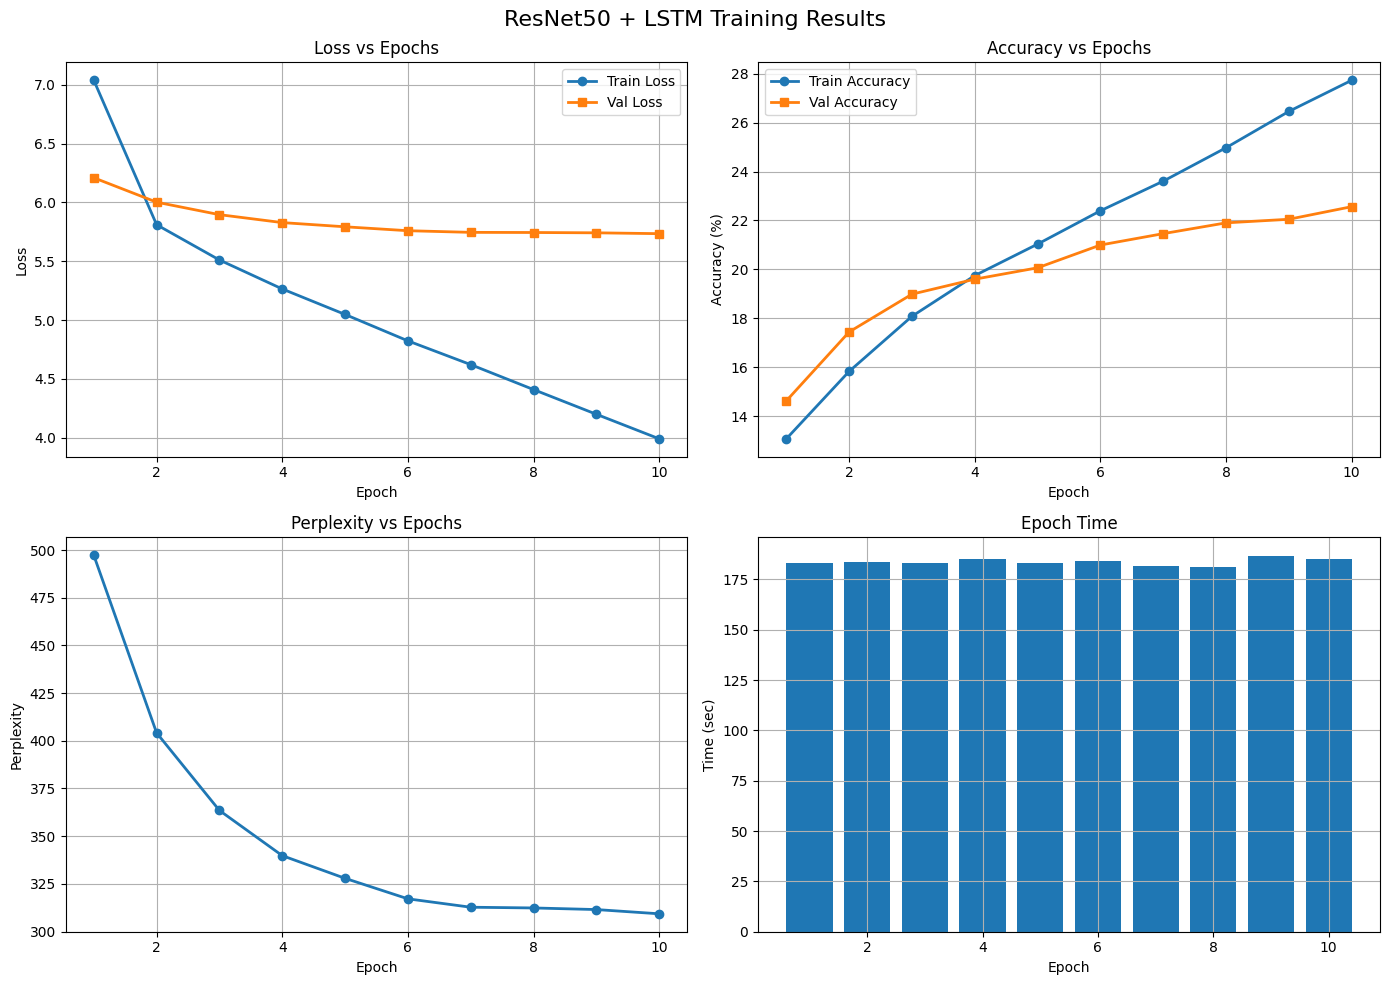

In [ ]:
# ==========================================
# ALL RESULTS VISUALIZATION IN ONE FIGURE
# ==========================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# ----------------------------------
# LOSS
# ----------------------------------

axes[0,0].plot(
    results_df["Epoch"],
    results_df["Train Loss"],
    marker="o",
    linewidth=2,
    label="Train Loss"
)

axes[0,0].plot(
    results_df["Epoch"],
    results_df["Val Loss"],
    marker="s",
    linewidth=2,
    label="Val Loss"
)

axes[0,0].set_title("Loss vs Epochs")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss")
axes[0,0].legend()
axes[0,0].grid(True)

# ----------------------------------
# ACCURACY
# ----------------------------------

axes[0,1].plot(
    results_df["Epoch"],
    results_df["Train Accuracy"],
    marker="o",
    linewidth=2,
    label="Train Accuracy"
)

axes[0,1].plot(
    results_df["Epoch"],
    results_df["Val Accuracy"],
    marker="s",
    linewidth=2,
    label="Val Accuracy"
)

axes[0,1].set_title("Accuracy vs Epochs")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Accuracy (%)")
axes[0,1].legend()
axes[0,1].grid(True)

# ----------------------------------
# PERPLEXITY
# ----------------------------------

axes[1,0].plot(
    results_df["Epoch"],
    results_df["Perplexity"],
    marker="o",
    linewidth=2
)

axes[1,0].set_title("Perplexity vs Epochs")
axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("Perplexity")
axes[1,0].grid(True)

# ----------------------------------
# EPOCH TIME
# ----------------------------------

axes[1,1].bar(
    results_df["Epoch"],
    results_df["Epoch Time (sec)"]
)

axes[1,1].set_title("Epoch Time")
axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("Time (sec)")
axes[1,1].grid(True)

# ----------------------------------

plt.suptitle(
    "ResNet50 + LSTM Training Results",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [ ]:
!pip install rouge-score nltk -q

In [ ]:
import torch
import pandas as pd
import numpy as np

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

In [ ]:
# Take 200 random samples from preprocessed test set
test_subset = test_df.sample(n=200, random_state=42)

# Create dataset object
test_dataset = ROCODataset(test_subset)

print("Test Samples:", len(test_dataset))

Test Samples: 200


In [ ]:
def generate_caption(image, max_len=20):

    model.eval()

    with torch.no_grad():

        features = model.encoder(
            image.unsqueeze(0).to(device)
        )

        caption_input = torch.tensor(
            [[word2idx["<START>"]]]
        ).to(device)

        output_sentence = []

        for _ in range(max_len):

            outputs = model.decoder(
                features,
                caption_input
            )

            predicted_id = outputs[:, -1, :].argmax(dim=1).item()

            word = idx2word[predicted_id]

            if word == "<END>":
                break

            output_sentence.append(word)

            caption_input = torch.cat(
                [
                    caption_input,
                    torch.tensor([[predicted_id]]).to(device)
                ],
                dim=1
            )

    return " ".join(output_sentence)

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import pandas as pd

smooth = SmoothingFunction().method1
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

results = []

for i in range(len(test_subset)):

    image, _ = test_dataset[i]

    true_caption = str(test_subset.iloc[i]["clean_caption"])

    predicted_caption = generate_caption(image)

    reference = [true_caption.split()]
    candidate = predicted_caption.split()

    # BLEU Scores
    bleu1 = sentence_bleu(
        reference,
        candidate,
        weights=(1, 0, 0, 0),
        smoothing_function=smooth
    )

    bleu2 = sentence_bleu(
        reference,
        candidate,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smooth
    )

    bleu3 = sentence_bleu(
        reference,
        candidate,
        weights=(0.33, 0.33, 0.33, 0),
        smoothing_function=smooth
    )

    bleu4 = sentence_bleu(
        reference,
        candidate,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    # ROUGE-L
    rouge_l = scorer.score(
        true_caption,
        predicted_caption
    )['rougeL'].fmeasure

    # METEOR
    meteor = meteor_score(
        [true_caption.split()],
        candidate
    )

    results.append([
        true_caption,
        predicted_caption,
        bleu1,
        bleu2,
        bleu3,
        bleu4,
        rouge_l,
        meteor
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "True Caption",
        "Predicted Caption",
        "BLEU-1",
        "BLEU-2",
        "BLEU-3",
        "BLEU-4",
        "ROUGE-L",
        "METEOR"
    ]
)

In [ ]:
print("\n===== Average Scores on Test Set =====")

print(f"BLEU-1  : {results_df['BLEU-1'].mean():.4f}")
print(f"BLEU-2  : {results_df['BLEU-2'].mean():.4f}")
print(f"BLEU-3  : {results_df['BLEU-3'].mean():.4f}")
print(f"BLEU-4  : {results_df['BLEU-4'].mean():.4f}")
print(f"ROUGE-L : {results_df['ROUGE-L'].mean():.4f}")
print(f"METEOR  : {results_df['METEOR'].mean():.4f}")


===== Average Scores on Test Set =====
BLEU-1  : 0.1164
BLEU-2  : 0.0305
BLEU-3  : 0.0159
BLEU-4  : 0.0112
ROUGE-L : 0.1335
METEOR  : 0.0854


In [ ]:
results_df[
    ["True Caption", "Predicted Caption"]
].head(10)

,True Caption,Predicted Caption
0,pertrochanteric fracture treated with imhs nail,<START> <UNK> computed image tomography of sca...
1,laterolateral radiograph of the skull of a 6ye...,<START> <UNK> computed image tomography of sca...
2,computed tomography chest before whole lung la...,<START> <UNK> computed image tomography of sca...
3,21yearold woman with metastatic carcinoid tumo...,<START> <UNK> computed image tomography of sca...
4,opening of distal end of choledochus to 3rd se...,<START> <UNK> computed image tomography of sca...
5,echocardiogram of twin a showing small pulmona...,<START> <UNK> computed image tomography of sca...
6,a contrastenhanced ct scan revealed a large he...,<START> computed computed tomography tomograph...
7,preoperative magnetic resonance imaging scans ...,<START> <UNK> computed image tomography of sca...
8,contrastenhanced computed tomography distended...,<START> computed computed tomography tomograph...
9,postoperative panorama view,<START> <UNK> computed image tomography of sca...


In [ ]:
scores = [
    results_df['BLEU-1'].mean(),
    results_df['BLEU-2'].mean(),
    results_df['BLEU-3'].mean(),
    results_df['BLEU-4'].mean(),
    results_df['ROUGE-L'].mean(),
    results_df['METEOR'].mean()
]

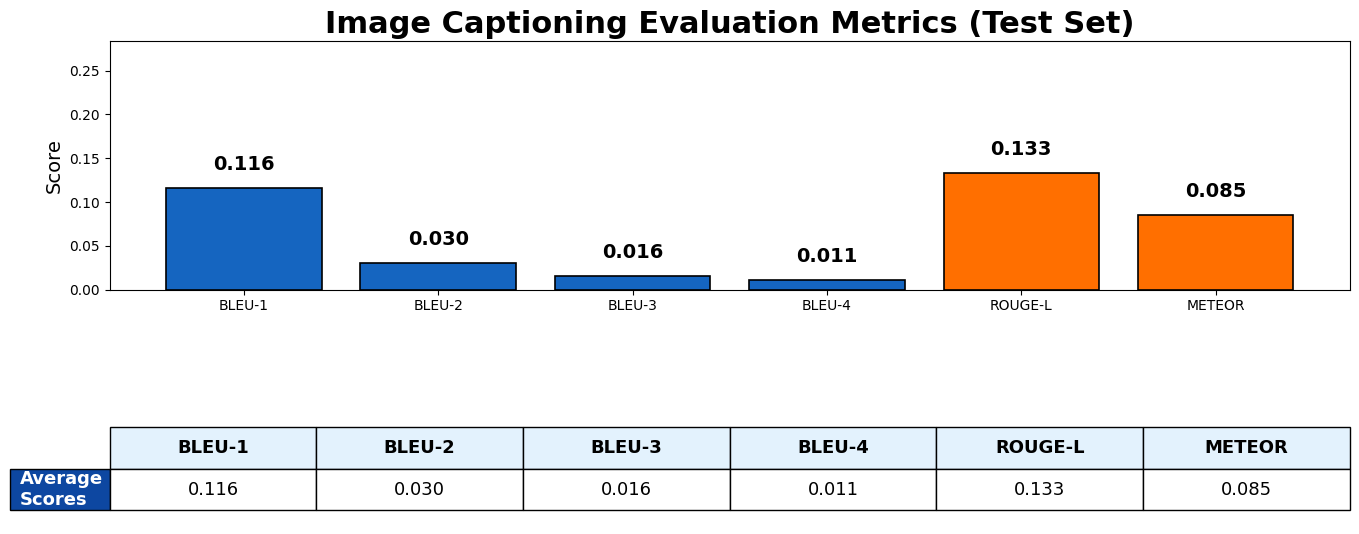

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===== Average Metrics =====
bleu1  = results_df['BLEU-1'].mean()
bleu2  = results_df['BLEU-2'].mean()
bleu3  = results_df['BLEU-3'].mean()
bleu4  = results_df['BLEU-4'].mean()
rouge  = results_df['ROUGE-L'].mean()
meteor = results_df['METEOR'].mean()

metrics = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4", "ROUGE-L", "METEOR"]
scores  = [bleu1, bleu2, bleu3, bleu4, rouge, meteor]

# ===== Figure Layout =====
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(
    3, 1,
    height_ratios=[2.3, 1.8, 0.8],
    hspace=0.55
)

# =====================================================
# 2. Metrics Bar Chart
# =====================================================
ax2 = fig.add_subplot(gs[1])

colors = [
    '#1565C0',
    '#1565C0',
    '#1565C0',
    '#1565C0',
    '#FF6F00',
    '#FF6F00'
]

bars = ax2.bar(
    metrics,
    scores,
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

ax2.set_title(
    'Image Captioning Evaluation Metrics (Test Set)',
    fontsize=22,
    fontweight='bold'
)

ax2.set_ylabel('Score', fontsize=14)
ax2.set_ylim(0, max(scores)+0.15)

for bar in bars:
    height = bar.get_height()

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'{height:.3f}',
        ha='center',
        fontsize=14,
        fontweight='bold'
    )

# =====================================================
# 3. Metrics Table
# =====================================================
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')

table = ax3.table(
    cellText=[[f"{x:.3f}" for x in scores]],
    colLabels=metrics,
    rowLabels=['Average\nScores'],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 2.5)

# Header Styling
for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#E3F2FD')

    if col == -1:
        cell.set_facecolor('#0D47A1')
        cell.set_text_props(
            color='white',
            weight='bold'
        )

# =====================================================
# Save High Quality Figure
# =====================================================
plt.savefig(
    'Image_Captioning_Results.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()